In [12]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

project_root = Path("/home/akapociu/ift/interactiondynamics")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from data.one_dimension_wave_binned import WaveEquationBinnedConfig, WaveEquationBinnedDataset


In [13]:
cfg = WaveEquationBinnedConfig(
    num_nodes= 32,
    num_bins= 256,
    event_mode="thresholded",
    interaction_threshold=0.0,
    threshold_metric="pair_accel",
    threshold_use_absolute=True,
    threshold_keep_one_if_empty=True,
)

ds = WaveEquationBinnedDataset(cfg)
spec = ds.spec()
spec

DataSpec(name='wave_equation_binned', num_nodes=32, event_dim=4, num_events=16384, num_bins=256, extra={'physics': '1D periodic wave equation in first-order form', 'interaction_view': 'pairwise nearest-neighbor spring-like coupling on a ring', 'state_layout': '[q_0..q_{N-1}, v_0..v_{N-1}]', 'split_fracs': (0.7, 0.15, 0.15), 't_span': (0.0, 20.0), 'dt': 0.0784313725490196, 'dx': 0.03125, 'domain_length': 1.0, 'wave_speed': 0.5, 'damping': 0.1, 'feature_names': ['rel_q', 'rel_v', 'pair_grad', 'pair_accel_contrib'], 'event_mode': 'thresholded', 'interaction_threshold': 0.0, 'threshold_metric': 'pair_accel', 'threshold_use_absolute': True, 'threshold_keep_one_if_empty': True, 'observation_noise_q': 0.0, 'observation_noise_v': 0.0, 'node_target_dim': 1, 'node_target_names': ['dv'], 'target_horizon': 0})

In [14]:
batch0 = next(iter(ds.bins("train")))
print(batch0.src[:10])
print(batch0.dst[:10])
print(batch0.features.shape if batch0.features is not None else None)
print(spec.extra)

tensor([31,  1,  0,  2,  1,  3,  2,  4,  3,  5])
tensor([0, 0, 1, 1, 2, 2, 3, 3, 4, 4])
torch.Size([64, 4])
{'physics': '1D periodic wave equation in first-order form', 'interaction_view': 'pairwise nearest-neighbor spring-like coupling on a ring', 'state_layout': '[q_0..q_{N-1}, v_0..v_{N-1}]', 'split_fracs': (0.7, 0.15, 0.15), 't_span': (0.0, 20.0), 'dt': 0.0784313725490196, 'dx': 0.03125, 'domain_length': 1.0, 'wave_speed': 0.5, 'damping': 0.1, 'feature_names': ['rel_q', 'rel_v', 'pair_grad', 'pair_accel_contrib'], 'event_mode': 'thresholded', 'interaction_threshold': 0.0, 'threshold_metric': 'pair_accel', 'threshold_use_absolute': True, 'threshold_keep_one_if_empty': True, 'observation_noise_q': 0.0, 'observation_noise_v': 0.0, 'node_target_dim': 1, 'node_target_names': ['dv'], 'target_horizon': 0}


THRESHOLD OPTIONS:

rel_q = q_j - q_i
- Displacement mismatch between neighboring nodes (grid sites)
- If neighbors are at similar displacement, edge looks weak and vice versa
- Simplest option

rel_v = v_j - v_i
- Velocity mismatch between neighbors
- Keep edges where nearby nodes are moving differently (more dynamic contrast rather than shape contrast)
- Less directly tied to spatial wave coupling term

pair_grad = (q_j - q_i)/dx
- Local spatial slope between neighbors
- Big if the wave is steep there, small if field is flat
- Good physical interpretatation for waves

pair_accel_contrib = c^2 (q_j - q_i)/dx^2
- Pairwise contribution to the receiver's acceleration from that neighbor
- Most directly tied to actual discrete wave equation
- How much is this node trying pull/push this site?
- Therefore, more physics faithful option (also very similar to spring-mass problem)


- For every candidate neighbor edge in every val bin, we look at the chosen edge feature values (with 300 bins and 64 edges per bin -> 19,3000 total candidate edges checked)
- Across all 19,200 possible neighbor interactions, how big is this quantity usually?

For example: 
=== pair_grad ===
count: 19200
min:   0.000665364
mean:  5.9719
std:   4.48648
max:   28.3768
p50:   5.09786
p75:   8.61607
p90:   12.1937
p95:   14.5258
p99:   19.0841

- 50% of the edge values are below 5.10 and half above it (p50)
- 75% are below 8.62, so the top 25% values are above that
- So if you set interaction_threshold = 8.61607, you are keeping only edges in the strongest top 25% by absolute local slope (value >= 8.61607)
- Pick percentile based on how sparse or dense you want each bin to be

feature_names: ['rel_q', 'rel_v', 'pair_grad', 'pair_accel_contrib']
metric_idx: {'pair_accel_contrib': 3, 'rel_q': 0, 'rel_v': 1, 'pair_grad': 2}
num bins inspected: 38
edges per bin (first few): [64, 64, 64, 64, 64, 64, 64, 64, 64, 64]
mean edges/bin: 64.00

=== pair_accel_contrib ===
count: 2432
min:   0.039724
mean:  13.1515
std:   10.0111
max:   58.9621
p50:   11.0496
p75:   19.0334
p90:   27.6114
p95:   32.8948
p99:   41.6884

=== rel_q ===
count: 2432
min:   0.000155172
mean:  0.051373
std:   0.0391059
max:   0.230321
p50:   0.0431624
p75:   0.0743492
p90:   0.107857
p95:   0.128495
p99:   0.162845

=== rel_v ===
count: 2432
min:   0.000307933
mean:  1.08418
std:   0.800711
max:   4.64803
p50:   0.918444
p75:   1.56031
p90:   2.19882
p95:   2.59378
p99:   3.49352

=== pair_grad ===
count: 2432
min:   0.0049655
mean:  1.64393
std:   1.25139
max:   7.37026
p50:   1.3812
p75:   2.37917
p90:   3.45142
p95:   4.11186
p99:   5.21105


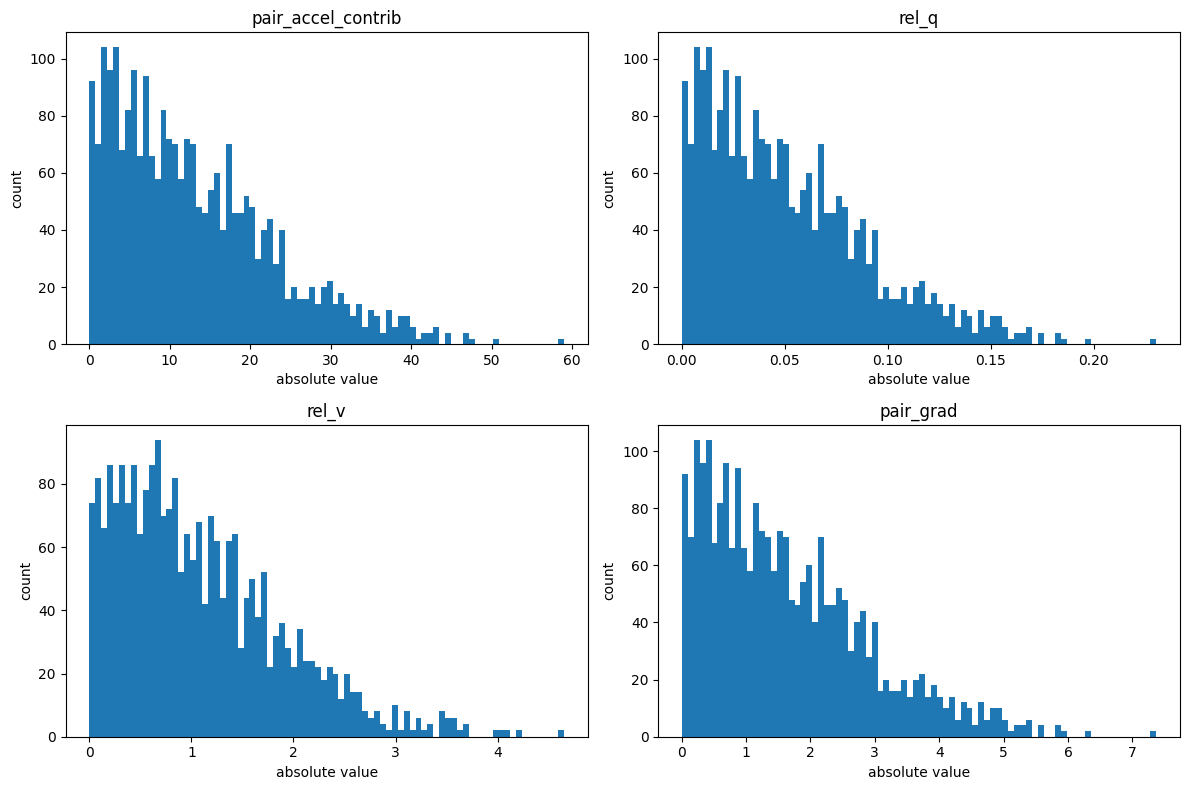


=== Estimated sparsity by percentile cutoff ===

--- pair_accel_contrib ---
p50 threshold = 11.0496 | mean kept/bin = 32.00 | min = 18 | max = 42
p75 threshold = 19.0334 | mean kept/bin = 16.00 | min = 4 | max = 30
p90 threshold = 27.6114 | mean kept/bin = 6.42 | min = 0 | max = 14
p95 threshold = 32.8948 | mean kept/bin = 3.21 | min = 0 | max = 10
p99 threshold = 41.6884 | mean kept/bin = 0.68 | min = 0 | max = 6

--- rel_q ---
p50 threshold = 0.0431624 | mean kept/bin = 32.00 | min = 18 | max = 42
p75 threshold = 0.0743492 | mean kept/bin = 16.00 | min = 4 | max = 30
p90 threshold = 0.107857 | mean kept/bin = 6.42 | min = 0 | max = 14
p95 threshold = 0.128495 | mean kept/bin = 3.21 | min = 0 | max = 10
p99 threshold = 0.162845 | mean kept/bin = 0.68 | min = 0 | max = 6

--- rel_v ---
p50 threshold = 0.918444 | mean kept/bin = 32.00 | min = 16 | max = 46
p75 threshold = 1.56031 | mean kept/bin = 16.00 | min = 2 | max = 28
p90 threshold = 2.19882 | mean kept/bin = 6.42 | min = 0 | max

In [15]:
# -----------------------------
# config
# -----------------------------
split = "val"          # or "val" / "test"
use_abs = True           # matches threshold_use_absolute=True
percentiles = [50, 75, 90, 95, 99]

# -----------------------------
# figure out feature names
# -----------------------------
feature_names = spec.extra.get("feature_names", None)
if feature_names is None:
    raise ValueError("spec.extra['feature_names'] not found")

feature_names = list(feature_names)
print("feature_names:", feature_names)

wanted_metrics = ["pair_accel_contrib", "rel_q", "rel_v", "pair_grad"]

missing = [m for m in wanted_metrics if m not in feature_names]
if missing:
    raise ValueError(f"Missing expected metrics in feature_names: {missing}")

metric_idx = {m: feature_names.index(m) for m in wanted_metrics}
print("metric_idx:", metric_idx)

# -----------------------------
# collect per-bin values
# -----------------------------
metric_values = {m: [] for m in wanted_metrics}
metric_values_by_bin = {m: [] for m in wanted_metrics}
edges_per_bin = []

for batch in ds.bins(split):
    if batch.features is None:
        continue

    feats = batch.features.detach().cpu().numpy()   # [num_edges, num_features]
    edges_per_bin.append(feats.shape[0])

    for m in wanted_metrics:
        vals = feats[:, metric_idx[m]]
        if use_abs:
            vals = np.abs(vals)

        metric_values[m].append(vals)
        metric_values_by_bin[m].append(vals)

print(f"num bins inspected: {len(edges_per_bin)}")
print(f"edges per bin (first few): {edges_per_bin[:10]}")
print(f"mean edges/bin: {np.mean(edges_per_bin):.2f}")

# concatenate all bins
for m in wanted_metrics:
    metric_values[m] = np.concatenate(metric_values[m]) if metric_values[m] else np.array([])

# -----------------------------
# summary stats
# -----------------------------
for m in wanted_metrics:
    vals = metric_values[m]
    print(f"\n=== {m} ===")
    print(f"count: {len(vals)}")
    print(f"min:   {vals.min():.6g}")
    print(f"mean:  {vals.mean():.6g}")
    print(f"std:   {vals.std():.6g}")
    print(f"max:   {vals.max():.6g}")
    for p in percentiles:
        print(f"p{p}:   {np.percentile(vals, p):.6g}")

# -----------------------------
# histograms
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, m in zip(axes, wanted_metrics):
    vals = metric_values[m]
    ax.hist(vals, bins=80)
    ax.set_title(m)
    ax.set_xlabel("absolute value" if use_abs else "value")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

# -----------------------------
# survival counts by percentile threshold
# -----------------------------
print("\n=== Estimated sparsity by percentile cutoff ===")
for m in wanted_metrics:
    print(f"\n--- {m} ---")
    all_vals = metric_values[m]

    for p in percentiles:
        thr = np.percentile(all_vals, p)

        kept_counts = []
        for vals_bin in metric_values_by_bin[m]:
            kept = (vals_bin >= thr).sum()
            kept_counts.append(int(kept))

        kept_counts = np.array(kept_counts)

        print(
            f"p{p:>2} threshold = {thr:.6g} | "
            f"mean kept/bin = {kept_counts.mean():.2f} | "
            f"min = {kept_counts.min()} | "
            f"max = {kept_counts.max()}"
        )

In [16]:
from collections import Counter
split = "val"

edge_counts = []   
for batch in ds.bins(split):
    n_edges = int(batch.src.numel())
    edge_counts.append(n_edges)

edge_counts = np.array(edge_counts)

print(f"=== Edge count stats for split={split!r} ===")
print(f"num_bins:         {len(edge_counts)}")
print(f"total_edges:      {edge_counts.sum()}")
print(f"min_edges/bin:    {edge_counts.min()}")
print(f"max_edges/bin:    {edge_counts.max()}")
print(f"mean_edges/bin:   {edge_counts.mean():.2f}")
print(f"median_edges/bin: {np.median(edge_counts):.2f}")
print(f"std_edges/bin:    {edge_counts.std():.2f}")
print(f"first 10 bins:    {edge_counts[:10].tolist()}")

count_freq = Counter(edge_counts.tolist())

print("\n=== Bin count frequency ===")
for edge_count in sorted(count_freq):
    print(f"{count_freq[edge_count]} bins have {edge_count} edges")

=== Edge count stats for split='val' ===
num_bins:         38
total_edges:      2432
min_edges/bin:    64
max_edges/bin:    64
mean_edges/bin:   64.00
median_edges/bin: 64.00
std_edges/bin:    0.00
first 10 bins:    [64, 64, 64, 64, 64, 64, 64, 64, 64, 64]

=== Bin count frequency ===
38 bins have 64 edges


full candidate edges per bin (wave): 64 = 2 * num_nodes
num bins inspected: 38

================ pair_accel_contrib ================



,metric,threshold_label,threshold,mean_kept/bin_pre_fallback,min_kept/bin_pre_fallback,max_kept/bin_pre_fallback,empty_bins_pre_fallback,fallback_fraction,unique_topologies,mean_hamming_vs_prev_bin,max_hamming_vs_prev_bin,mean_edges_near_threshold,max_edges_near_threshold
0,pair_accel_contrib,p50,11.049586,32.000000,18,42,0,0.000000,38,32.324324,44,5.631579,14
1,pair_accel_contrib,p75,19.033400,16.000000,4,30,0,0.000000,38,24.432432,38,4.052632,10
2,pair_accel_contrib,p90,27.611400,6.421053,0,14,2,0.052632,36,11.081081,20,1.368421,4
3,pair_accel_contrib,p95,32.894856,3.210526,0,10,10,0.263158,27,5.837838,12,1.052632,4
4,pair_accel_contrib,p99,41.688408,0.684211,0,6,27,0.710526,9,1.243243,8,0.263158,4



================ rel_q ================



,metric,threshold_label,threshold,mean_kept/bin_pre_fallback,min_kept/bin_pre_fallback,max_kept/bin_pre_fallback,empty_bins_pre_fallback,fallback_fraction,unique_topologies,mean_hamming_vs_prev_bin,max_hamming_vs_prev_bin,mean_edges_near_threshold,max_edges_near_threshold
0,rel_q,p50,0.043162,32.000000,18,42,0,0.000000,38,32.324324,44,5.631579,14
1,rel_q,p75,0.074349,16.000000,4,30,0,0.000000,38,24.432432,38,4.052632,10
2,rel_q,p90,0.107857,6.421053,0,14,2,0.052632,36,11.081081,20,1.368421,4
3,rel_q,p95,0.128496,3.210526,0,10,10,0.263158,27,5.837838,12,1.052632,4
4,rel_q,p99,0.162845,0.684211,0,6,27,0.710526,9,1.243243,8,0.263158,4



================ rel_v ================



,metric,threshold_label,threshold,mean_kept/bin_pre_fallback,min_kept/bin_pre_fallback,max_kept/bin_pre_fallback,empty_bins_pre_fallback,fallback_fraction,unique_topologies,mean_hamming_vs_prev_bin,max_hamming_vs_prev_bin,mean_edges_near_threshold,max_edges_near_threshold
0,rel_v,p50,0.918444,32.000000,16,46,0,0.000000,38,28.756757,40,5.526316,10
1,rel_v,p75,1.560306,16.000000,2,28,0,0.000000,38,22.216216,36,3.315789,10
2,rel_v,p90,2.198821,6.421053,0,14,2,0.052632,35,9.891892,18,1.736842,6
3,rel_v,p95,2.593784,3.210526,0,8,10,0.263158,25,5.135135,12,1.263158,6
4,rel_v,p99,3.493516,0.684211,0,4,27,0.710526,10,1.243243,6,0.526316,4



================ pair_grad ================



,metric,threshold_label,threshold,mean_kept/bin_pre_fallback,min_kept/bin_pre_fallback,max_kept/bin_pre_fallback,empty_bins_pre_fallback,fallback_fraction,unique_topologies,mean_hamming_vs_prev_bin,max_hamming_vs_prev_bin,mean_edges_near_threshold,max_edges_near_threshold
0,pair_grad,p50,1.381198,32.000000,18,42,0,0.000000,38,32.324324,44,5.631579,14
1,pair_grad,p75,2.379175,16.000000,4,30,0,0.000000,38,24.432432,38,4.052632,10
2,pair_grad,p90,3.451425,6.421053,0,14,2,0.052632,36,11.081081,20,1.368421,4
3,pair_grad,p95,4.111857,3.210526,0,10,10,0.263158,27,5.837838,12,1.052632,4
4,pair_grad,p99,5.211051,0.684211,0,6,27,0.710526,9,1.243243,8,0.263158,4


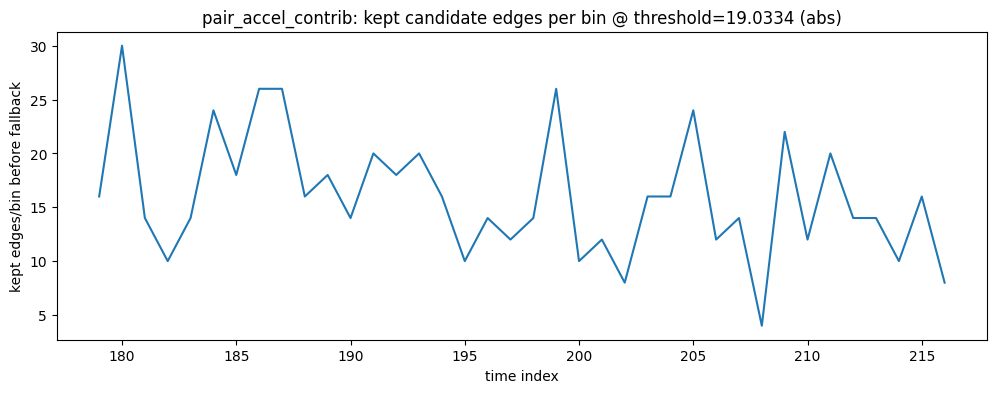

In [18]:
# ============================================================
# EXTENSION: debug FULL candidate wave edges, not just survivors
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# sanity: this only works for the wave dataset object
# -----------------------------
if not hasattr(ds, "trajectory"):
    raise ValueError("This extension expects ds.trajectory() (WaveEquationBinnedDataset).")

if not hasattr(ds, "cfg"):
    raise ValueError("This extension expects ds.cfg.")

cfg = ds.cfg
q_traj, v_traj, t_eval = ds.trajectory()

# use the same split setting you already defined above
split_batches = list(ds.bins(split))
t_idxs = [int(b.t[0].item()) for b in split_batches]

N = cfg.num_nodes
dx = cfg.domain_length / float(cfg.num_nodes)
c = cfg.wave_speed

wanted_metrics = ["pair_accel_contrib", "rel_q", "rel_v", "pair_grad"]

# -----------------------------
# build ALL candidate nearest-neighbor edges for each bin
# -----------------------------
def build_full_candidate_metrics_for_bin(q, v, cfg):
    """
    Reconstruct the full 2N directed nearest-neighbor candidate edges
    for one wave snapshot, BEFORE thresholding / fallback.
    """
    N = len(q)
    dx = cfg.domain_length / float(cfg.num_nodes)
    c = cfg.wave_speed

    out = {m: [] for m in wanted_metrics}
    edge_labels = []  # (src, dst)

    for recv in range(N):
        left = (recv - 1) % N
        right = (recv + 1) % N

        for send in [left, right]:
            rel_q = float(q[send] - q[recv])
            rel_v = float(v[send] - v[recv])
            pair_grad = rel_q / dx
            pair_accel_contrib = (c ** 2) * rel_q / (dx ** 2)

            out["rel_q"].append(rel_q)
            out["rel_v"].append(rel_v)
            out["pair_grad"].append(pair_grad)
            out["pair_accel_contrib"].append(pair_accel_contrib)

            edge_labels.append((send, recv))

    out = {k: np.asarray(vs) for k, vs in out.items()}
    return out, edge_labels

candidate_values_by_bin = {m: [] for m in wanted_metrics}
edge_labels_ref = None

for t_idx in t_idxs:
    q = q_traj[t_idx]
    v = v_traj[t_idx]
    metric_dict, edge_labels = build_full_candidate_metrics_for_bin(q, v, cfg)

    if edge_labels_ref is None:
        edge_labels_ref = edge_labels

    for m in wanted_metrics:
        vals = metric_dict[m]
        if use_abs:
            vals = np.abs(vals)
        candidate_values_by_bin[m].append(vals)

full_edges_per_bin = [len(edge_labels_ref)] * len(t_idxs)
print(f"full candidate edges per bin (wave): {full_edges_per_bin[0]} = 2 * num_nodes")
print(f"num bins inspected: {len(t_idxs)}")

# -----------------------------
# helper: summarize one metric across thresholds
# -----------------------------
def summarize_threshold_behavior(
    metric,
    percentiles=(50, 75, 90, 95, 99),
    custom_thresholds=None,
    near_frac=0.02,   # "near threshold" band = 2% of global value range
):
    vals_by_bin = candidate_values_by_bin[metric]
    all_vals = np.concatenate(vals_by_bin)

    rows = []

    thr_list = []
    for p in percentiles:
        thr_list.append((f"p{p}", float(np.percentile(all_vals, p))))
    if custom_thresholds is not None:
        for thr in custom_thresholds:
            thr_list.append((f"custom_{thr:.6g}", float(thr)))

    value_range = max(1e-12, float(all_vals.max() - all_vals.min()))
    near_eps = near_frac * value_range

    for label, thr in thr_list:
        kept_counts = []
        empty_bins = 0
        fallback_bins = 0
        topology_patterns = []
        hamming_to_prev = []
        near_threshold_counts = []

        prev_mask = None

        for vals in vals_by_bin:
            mask = vals >= thr
            kept = int(mask.sum())

            kept_counts.append(kept)
            if kept == 0:
                empty_bins += 1
                fallback_bins += 1  # wave code would keep max edge if empty

            topology_patterns.append(tuple(np.flatnonzero(mask)))
            near_threshold_counts.append(int(np.sum(np.abs(vals - thr) <= near_eps)))

            if prev_mask is not None:
                hamming_to_prev.append(int(np.sum(mask != prev_mask)))
            prev_mask = mask.copy()

        kept_counts = np.asarray(kept_counts)
        unique_patterns = len(set(topology_patterns))

        rows.append({
            "metric": metric,
            "threshold_label": label,
            "threshold": thr,
            "mean_kept/bin_pre_fallback": kept_counts.mean(),
            "min_kept/bin_pre_fallback": kept_counts.min(),
            "max_kept/bin_pre_fallback": kept_counts.max(),
            "empty_bins_pre_fallback": empty_bins,
            "fallback_fraction": fallback_bins / len(vals_by_bin),
            "unique_topologies": unique_patterns,
            "mean_hamming_vs_prev_bin": np.mean(hamming_to_prev) if hamming_to_prev else 0.0,
            "max_hamming_vs_prev_bin": np.max(hamming_to_prev) if hamming_to_prev else 0,
            "mean_edges_near_threshold": np.mean(near_threshold_counts),
            "max_edges_near_threshold": np.max(near_threshold_counts),
        })

    return pd.DataFrame(rows)

# -----------------------------
# run summaries for each metric
# -----------------------------
debug_tables = {}
for m in wanted_metrics:
    df = summarize_threshold_behavior(
        metric=m,
        percentiles=percentiles,
        custom_thresholds=None,   # you can pass exact cursed thresholds here later
        near_frac=0.02,
    )
    debug_tables[m] = df
    print(f"\n================ {m} ================\n")
    display(df)

# -----------------------------
# helper: inspect one metric around a suspicious threshold
# -----------------------------
def inspect_metric_around_threshold(metric, center_thr, deltas=(-1e-3, -1e-4, 0.0, 1e-4, 1e-3)):
    vals_by_bin = candidate_values_by_bin[metric]
    rows = []

    for d in deltas:
        thr = center_thr + d
        kept_counts = []
        topology_patterns = []
        prev_mask = None
        hamming_to_prev = []

        for vals in vals_by_bin:
            mask = vals >= thr
            kept_counts.append(int(mask.sum()))
            topology_patterns.append(tuple(np.flatnonzero(mask)))

            if prev_mask is not None:
                hamming_to_prev.append(int(np.sum(mask != prev_mask)))
            prev_mask = mask.copy()

        rows.append({
            "metric": metric,
            "threshold": thr,
            "delta": d,
            "mean_kept/bin": np.mean(kept_counts),
            "min_kept/bin": np.min(kept_counts),
            "max_kept/bin": np.max(kept_counts),
            "unique_topologies": len(set(topology_patterns)),
            "mean_hamming_vs_prev_bin": np.mean(hamming_to_prev) if hamming_to_prev else 0.0,
            "max_hamming_vs_prev_bin": np.max(hamming_to_prev) if hamming_to_prev else 0,
            "empty_bins_pre_fallback": int(np.sum(np.array(kept_counts) == 0)),
        })

    out = pd.DataFrame(rows)
    display(out)
    return out

# -----------------------------
# helper: visualize kept edges over time for one metric/threshold
# -----------------------------
def plot_kept_edges_over_time(metric, thr):
    vals_by_bin = candidate_values_by_bin[metric]
    kept_counts = [int((vals >= thr).sum()) for vals in vals_by_bin]

    plt.figure(figsize=(12, 4))
    plt.plot(t_idxs, kept_counts)
    plt.title(f"{metric}: kept candidate edges per bin @ threshold={thr:.6g} ({'abs' if use_abs else 'signed'})")
    plt.xlabel("time index")
    plt.ylabel("kept edges/bin before fallback")
    plt.show()

# -----------------------------
# helper: show which exact edges survive in a chosen bin
# -----------------------------
def show_bin_topology(metric, thr, bin_idx_in_split=0):
    vals = candidate_values_by_bin[metric][bin_idx_in_split]
    mask = vals >= thr
    kept_edges = [edge_labels_ref[i] for i in np.flatnonzero(mask)]

    print(f"split bin idx: {bin_idx_in_split}")
    print(f"global t_idx: {t_idxs[bin_idx_in_split]}")
    print(f"threshold: {thr:.6g}")
    print(f"kept edges ({len(kept_edges)}):")
    print(kept_edges[:50])

# ============================================================
# EXAMPLES
# ============================================================

# 1) inspect the official percentile thresholds you already use
pair_df = debug_tables["pair_accel_contrib"]
relq_df = debug_tables["rel_q"]
relv_df = debug_tables["rel_v"]

# 2) if one exact threshold seemed cursed, inspect nearby values
# inspect_metric_around_threshold("pair_accel_contrib", center_thr=19.0334, deltas=(-0.5, -0.1, 0.0, 0.1, 0.5))

# 3) plot how many edges survive over time
plot_kept_edges_over_time("pair_accel_contrib", thr=19.0334)

# 4) inspect a specific bin's surviving topology
# show_bin_topology("pair_accel_contrib", thr=19.0334, bin_idx_in_split=10)